### Pripojenie Google Drive

In [1]:
from google.colab import drive
import os

# Uistíme sa, že disk je pripojený
drive.mount('/content/drive')

# Vypíšeme všetky priečinky pre manuálnu kontrolu
print("Zoznam priečinkov na My Drive:")
my_drive_path = '/content/drive/MyDrive/'
folders = [f for f in os.listdir(my_drive_path) if os.path.isdir(os.path.join(my_drive_path, f))]
for f in folders:
    print(f" - {f}")

# Skúsime automaticky nájsť priečinok, ktorý obsahuje CSV súbory
print("\nHľadám Fashion-MNIST súbory...")
found_path = None
for root, dirs, files in os.walk(my_drive_path):
    if 'fashion-mnist_train.csv' in files:
        found_path = root
        break

if found_path:
    print(f"✅ Našiel som dáta v: {found_path}")
    print("Obsah:", os.listdir(found_path))
else:
    print("❌ Súbor 'fashion-mnist_train.csv' sa nenašiel. Uistite sa, že ste si priečinok z linku pridali na svoj disk (Skratka / Shortcut).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zoznam priečinkov na My Drive:
 - Office 2016.zip (Unzipped Files)
 - Riša merania
 - Testy
 - ima2c
 - zmluva
 - birmovka
 - knn
 - musicology
 - Colab Notebooks
 - VYF2
 - VYF3
 - VYF1
 - VYF
 - CV
 - SportsClassifier
 - small-e-czech-sport
 - small-e-czech-sport_clean_merged
 - small-e-czech-sport_clean_aug
 - small-e-czech-sport_clean_aug_focus2
 - small-e-czech-sport_clean_aug_focus_w07
 - small-e-czech-sport_clean_aug_focus_w1
 - small-e-czech-sport_clean_aug_focus_w13
 - small-e-czech-sport_clean_aug_focus_w07epoch5
 - small-e-czech-sport_clean_aug_focus_train
 - chatarena
 - AIBiz-2026-spring

Hľadám Fashion-MNIST súbory...
✅ Našiel som dáta v: /content/drive/MyDrive/AIBiz-2026-spring/ai-biz-2026-spring-task-3
Obsah: ['fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'fashion-mnist_test_sample_submission.csv']


# Fashion-MNIST Task 3: Transfer Learning with EfficientNet

This notebook trains an EfficientNetB0-based classifier for Fashion-MNIST CSV data and creates `submission.csv` in the main folder.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATA_DIR = '/content/drive/MyDrive/AIBiz-2026-spring/ai-biz-2026-spring-task-3'

TRAIN_PATH = os.path.join(DATA_DIR, 'fashion-mnist_train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'fashion-mnist_test.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'fashion-mnist_test_sample_submission.csv')

assert os.path.exists(TRAIN_PATH), f'Missing: {TRAIN_PATH}'
assert os.path.exists(TEST_PATH), f'Missing: {TEST_PATH}'
assert os.path.exists(SAMPLE_SUB_PATH), f'Missing: {SAMPLE_SUB_PATH}'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print(sample_sub.head())

Train shape: (60000, 785)
Test shape: (10000, 784)
   imageID  label
0        0      2
1        1      1
2        2      9
3        3      1
4        4      6


In [4]:
# Prepare arrays and single train/val split
y = train_df['label'].values.astype(np.int64)
X = train_df.drop(columns=['label']).values.astype(np.float32) / 255.0
X_test = test_df.values.astype(np.float32) / 255.0

X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=SEED, stratify=y
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape)

X_train: (54000, 28, 28, 1) y_train: (54000,)
X_val: (6000, 28, 28, 1) y_val: (6000,)
X_test: (10000, 28, 28, 1)


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 512
AUTO = tf.data.AUTOTUNE
NUM_CLASSES = 10
MIXUP_ALPHA = 0.05
LABEL_SMOOTHING = 0.03
EPOCHS_HEAD = 6
EPOCHS_FT = 3
FOCAL_GAMMA = 2.2  # Increased from 1.5 for stronger focusing on hard Shirt vs Coat boundary

CUTOUT_PROB = 0.35

# Hard replay settings (stabilized for Colab memory)
HARD_REPLAY_EPOCHS = 1
HARD_REPLAY_MULTIPLIER = 2
HARD_CUTOUT_PROB = 0.5
HARD_BATCH_SIZE = 64
MAX_HARD_SAMPLES = 2500

# Shirt-focused balancing inside hard mining
SHIRT_CLASS = 6
SHIRT_CONFUSION_CLASSES = [0, 2, 4]
SHIRT_FN_TARGET_FRAC = 0.45
SHIRT_FP_TARGET_FRAC = 0.35

# Fokus na triedy s F1 < 0.90 z reportu: 0,2,3,4,6
LOW_F1_CLASSES = [0, 2, 3, 4, 6]
LOW_F1_CLASSES_TF = tf.constant(LOW_F1_CLASSES, dtype=tf.int32)
CLASS_WEIGHTS = tf.constant([1.25, 1.00, 1.20, 1.15, 1.20, 1.00, 1.90, 1.00, 1.00, 1.00], dtype=tf.float32)

def preprocess_for_efficientnet(image, label=None, one_hot=False, training=False, cutout_prob=None):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.image.grayscale_to_rgb(image)
    image = tf.keras.applications.efficientnet.preprocess_input(image * 255.0)

    if cutout_prob is None:
        cutout_prob = CUTOUT_PROB

    if training and label is not None:
        label_int = tf.cast(label, tf.int32)
        is_low_f1_class = tf.reduce_any(tf.equal(label_int, LOW_F1_CLASSES_TF))
        image = tf.cond(
            is_low_f1_class,
            lambda: random_cutout(image, prob=cutout_prob),
            lambda: image
        )

    if label is None:
        return image
    if one_hot:
        label = tf.one_hot(tf.cast(label, tf.int32), depth=NUM_CLASSES)
    return image, label

def random_cutout(image, prob=0.5, min_frac=0.10, max_frac=0.28):
    if tf.random.uniform([]) > prob:
        return image

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    cut_h = tf.cast(tf.cast(h, tf.float32) * tf.random.uniform([], min_frac, max_frac), tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * tf.random.uniform([], min_frac, max_frac), tf.int32)

    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)

    y1 = tf.clip_by_value(cy - cut_h // 2, 0, h)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, h)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, w)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, w)

    ys = tf.range(h)[:, None]
    xs = tf.range(w)[None, :]
    mask_2d = tf.logical_or(
        tf.logical_or(ys < y1, ys >= y2),
        tf.logical_or(xs < x1, xs >= x2)
    )
    mask = tf.cast(mask_2d[..., None], image.dtype)
    fill = tf.zeros_like(image)
    return image * mask + fill * (1.0 - mask)

def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    batch_size = tf.shape(images)[0]
    gamma1 = tf.random.gamma([batch_size], alpha, 1.0)
    gamma2 = tf.random.gamma([batch_size], alpha, 1.0)
    lam = gamma1 / (gamma1 + gamma2)

    indices = tf.random.shuffle(tf.range(batch_size))
    images2 = tf.gather(images, indices)
    labels2 = tf.gather(labels, indices)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    mixed_images = lam_x * images + (1.0 - lam_x) * images2
    mixed_labels = lam_y * labels + (1.0 - lam_y) * labels2
    return mixed_images, mixed_labels

def add_sample_weights(images, labels):
    sample_weights = tf.reduce_sum(labels * CLASS_WEIGHTS, axis=1)
    return images, labels, sample_weights

def get_focal_loss(gamma=FOCAL_GAMMA):
    if hasattr(keras.losses, 'CategoricalFocalCrossentropy'):
        return keras.losses.CategoricalFocalCrossentropy(gamma=gamma)

    def focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1.0 - keras.backend.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        modulating = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(modulating * ce, axis=-1)

    return focal_loss

def make_eval_dataset(X_data, y_data):
    ds = tf.data.Dataset.from_tensor_slices((X_data, y_data))
    ds = ds.map(
        lambda x, y: preprocess_for_efficientnet(x, y, one_hot=False, training=False),
        num_parallel_calls=AUTO
    ).batch(BATCH_SIZE).prefetch(AUTO)
    return ds

def make_hard_replay_dataset(X_hard, y_hard):
    ds = tf.data.Dataset.from_tensor_slices((X_hard, y_hard))
    ds = ds.shuffle(len(X_hard), seed=SEED)
    ds = ds.map(
        lambda x, y: preprocess_for_efficientnet(
            x, y, one_hot=True, training=True, cutout_prob=HARD_CUTOUT_PROB
        ),
        num_parallel_calls=AUTO
    ).batch(HARD_BATCH_SIZE)
    ds = ds.map(add_sample_weights, num_parallel_calls=AUTO)

    boosted = ds
    for _ in range(HARD_REPLAY_MULTIPLIER - 1):
        boosted = boosted.concatenate(ds)

    return boosted.prefetch(AUTO)

def make_train_val_test_datasets(X_train, y_train, X_val, y_val, X_test):
    base_train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    base_train_ds = base_train_ds.shuffle(len(X_train), seed=SEED)
    base_train_ds = base_train_ds.map(
        lambda x, y: preprocess_for_efficientnet(x, y, one_hot=True, training=True),
        num_parallel_calls=AUTO
    ).batch(BATCH_SIZE)

    train_head_ds = base_train_ds.map(mixup_batch, num_parallel_calls=AUTO)
    train_head_ds = train_head_ds.map(add_sample_weights, num_parallel_calls=AUTO).prefetch(AUTO)

    train_ft_ds = base_train_ds.map(add_sample_weights, num_parallel_calls=AUTO).prefetch(AUTO)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_ds = val_ds.map(
        lambda x, y: preprocess_for_efficientnet(x, y, one_hot=True, training=False),
        num_parallel_calls=AUTO
    ).batch(BATCH_SIZE)
    val_ds = val_ds.map(add_sample_weights, num_parallel_calls=AUTO).prefetch(AUTO)

    test_ds = tf.data.Dataset.from_tensor_slices(X_test)
    test_ds = test_ds.map(
        lambda x: preprocess_for_efficientnet(x, None, training=False),
        num_parallel_calls=AUTO
    ).batch(BATCH_SIZE).prefetch(AUTO)

    return train_head_ds, train_ft_ds, val_ds, test_ds

In [6]:
# Build transfer learning model factory
def build_model():
    data_aug = keras.Sequential([
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_aug(inputs)

    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=x
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model, base

model, base = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
# Single split training (bez 5-fold) so zameranim na slabe triedy
train_head_ds, train_ft_ds, val_ds, test_ds = make_train_val_test_datasets(
    X_train, y_train, X_val, y_val, X_test
)
val_pred_ds = val_ds.map(lambda x, y, w: x, num_parallel_calls=AUTO).prefetch(AUTO)

model, base = build_model()

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
    ),
]

# Stage 1: head training with FOCAL LOSS to focus on hard boundaries from the start
print(f"=== Stage 1: Head Training (Focal Loss, gamma={FOCAL_GAMMA}) ===")
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=get_focal_loss(gamma=FOCAL_GAMMA),
    metrics=['accuracy']
 )
model.fit(
    train_head_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
    verbose=1
)

# Stage 2: focused fine-tuning with STRONGER focal loss
print(f"\n=== Stage 2: Fine-tuning (Focal Loss, gamma={FOCAL_GAMMA}) ===")
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=get_focal_loss(gamma=FOCAL_GAMMA),
    metrics=['accuracy']
 )
model.fit(
    train_ft_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks,
    verbose=1
)

# Baseline before hard replay
val_probs_raw_pre = model.predict(val_pred_ds, verbose=0)
val_pred_pre = np.argmax(val_probs_raw_pre, axis=1)
val_acc_pre = accuracy_score(y_val, val_pred_pre)
shirt_f1_pre = f1_score(
    (y_val == SHIRT_CLASS).astype(int),
    (val_pred_pre == SHIRT_CLASS).astype(int)
 )
print(f'Before hard replay -> val_acc: {val_acc_pre:.5f}, shirt_f1: {shirt_f1_pre:.5f}')

best_weights_before_replay = model.get_weights()

# Stage 3: hard-example replay on low-F1 classes and confusing negatives
print(f"\n=== Stage 3: Hard-Replay (Focal Loss on hard Shirt samples) ===")
train_eval_ds = make_eval_dataset(X_train, y_train)
train_probs = model.predict(train_eval_ds, verbose=0)
train_pred = np.argmax(train_probs, axis=1)

low_f1_true = np.isin(y_train, LOW_F1_CLASSES)
low_f1_pred = np.isin(train_pred, LOW_F1_CLASSES)
misclassified = train_pred != y_train
hard_mask = misclassified & (low_f1_true | low_f1_pred)
hard_idx = np.where(hard_mask)[0]

# Balanced Shirt replay: both Shirt false negatives and false positives
shirt_fn_idx = np.where((y_train == SHIRT_CLASS) & (train_pred != SHIRT_CLASS))[0]
shirt_fp_idx = np.where((y_train != SHIRT_CLASS) & (train_pred == SHIRT_CLASS))[0]
shirt_fp_conf_idx = np.where(
    (y_train != SHIRT_CLASS) &
    (train_pred == SHIRT_CLASS) &
    np.isin(y_train, SHIRT_CONFUSION_CLASSES)
)[0]

n_fn_target = int(MAX_HARD_SAMPLES * SHIRT_FN_TARGET_FRAC)
n_fp_target = int(MAX_HARD_SAMPLES * SHIRT_FP_TARGET_FRAC)

sel_fn = shirt_fn_idx if len(shirt_fn_idx) <= n_fn_target else np.random.choice(shirt_fn_idx, size=n_fn_target, replace=False)
fp_pool = shirt_fp_conf_idx if len(shirt_fp_conf_idx) > 0 else shirt_fp_idx
sel_fp = fp_pool if len(fp_pool) <= n_fp_target else np.random.choice(fp_pool, size=n_fp_target, replace=False)

used = np.concatenate([sel_fn, sel_fp]) if (len(sel_fn) + len(sel_fp)) > 0 else np.array([], dtype=np.int64)
remaining = MAX_HARD_SAMPLES - len(used)
other_pool = np.setdiff1d(hard_idx, used, assume_unique=False)
if remaining > 0 and len(other_pool) > 0:
    sel_other = other_pool if len(other_pool) <= remaining else np.random.choice(other_pool, size=remaining, replace=False)
    selected_idx = np.concatenate([used, sel_other]) if len(used) > 0 else sel_other
else:
    selected_idx = used if len(used) > 0 else hard_idx

if len(selected_idx) > MAX_HARD_SAMPLES:
    selected_idx = np.random.choice(selected_idx, size=MAX_HARD_SAMPLES, replace=False)

print(f'Hard replay samples (selected): {len(selected_idx)}')
print(f'Shirt FN selected: {len(sel_fn)} | Shirt FP selected: {len(sel_fp)}')

val_probs_raw_after = val_probs_raw_pre
val_acc_after = val_acc_pre
shirt_f1_after = shirt_f1_pre

if len(selected_idx) >= 32:
    X_hard = X_train[selected_idx]
    y_hard = y_train[selected_idx]
    hard_replay_ds = make_hard_replay_dataset(X_hard, y_hard)

    model.compile(
        optimizer=keras.optimizers.Adam(5e-6),
        loss=get_focal_loss(gamma=FOCAL_GAMMA),
        metrics=['accuracy']
    )
    try:
        model.fit(
            hard_replay_ds,
            epochs=HARD_REPLAY_EPOCHS,
            verbose=1
        )
    except tf.errors.ResourceExhaustedError:
        print('Hard replay OOM, retrying with smaller batch...')
        HARD_BATCH_SIZE = 32
        hard_replay_ds = make_hard_replay_dataset(X_hard, y_hard)
        model.fit(hard_replay_ds, epochs=1, verbose=1)

    val_probs_raw_after = model.predict(val_pred_ds, verbose=0)
    val_pred_after = np.argmax(val_probs_raw_after, axis=1)
    val_acc_after = accuracy_score(y_val, val_pred_after)
    shirt_f1_after = f1_score(
        (y_val == SHIRT_CLASS).astype(int),
        (val_pred_after == SHIRT_CLASS).astype(int)
    )
    print(f'After hard replay  -> val_acc: {val_acc_after:.5f}, shirt_f1: {shirt_f1_after:.5f}')

    # Keep replay only if it does not degrade metrics materially
    shirt_drop = shirt_f1_after < (shirt_f1_pre - 0.002)
    acc_drop = val_acc_after < (val_acc_pre - 0.003)
    if shirt_drop or acc_drop:
        print('Hard replay degraded performance, restoring pre-replay weights.')
        model.set_weights(best_weights_before_replay)
        val_probs_raw = val_probs_raw_pre
    else:
        val_probs_raw = val_probs_raw_after
else:
    print('Skipping hard replay (not enough hard samples).')
    val_probs_raw = val_probs_raw_pre

# Stage 4: validation-tuned Shirt calibration (post-processing)
print(f"\n=== Stage 4: Shirt Calibration (post-processing) ===")
def calibrate_shirt_probs(probs, alpha, bias, shirt_class=SHIRT_CLASS):
    adj = probs.copy()
    adj[:, shirt_class] = np.clip(alpha * adj[:, shirt_class] + bias, 1e-8, 1.0)
    adj = adj / np.sum(adj, axis=1, keepdims=True)
    return adj

raw_val_pred = np.argmax(val_probs_raw, axis=1)
raw_shirt_f1 = f1_score((y_val == SHIRT_CLASS).astype(int), (raw_val_pred == SHIRT_CLASS).astype(int))

best_alpha = 1.0
best_bias = 0.0
best_shirt_f1 = raw_shirt_f1

for alpha in np.arange(0.70, 1.31, 0.05):
    for bias in np.arange(-0.12, 0.121, 0.01):
        val_probs_try = calibrate_shirt_probs(val_probs_raw, alpha, bias)
        val_pred_try = np.argmax(val_probs_try, axis=1)
        shirt_f1_try = f1_score(
            (y_val == SHIRT_CLASS).astype(int),
            (val_pred_try == SHIRT_CLASS).astype(int)
        )
        if shirt_f1_try > best_shirt_f1:
            best_shirt_f1 = shirt_f1_try
            best_alpha = alpha
            best_bias = bias

print(f'Shirt calibration: raw_f1={raw_shirt_f1:.4f} -> tuned_f1={best_shirt_f1:.4f} (alpha={best_alpha:.2f}, bias={best_bias:.2f})')

val_probs = calibrate_shirt_probs(val_probs_raw, best_alpha, best_bias)
val_pred = np.argmax(val_probs, axis=1)
val_acc = accuracy_score(y_val, val_pred)
print(f'Validation accuracy: {val_acc:.5f}')

test_probs_raw = model.predict(test_ds, verbose=0)

=== Stage 1: Head Training (Focal Loss, gamma=2.2) ===
Epoch 1/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.6664 - loss: 0.1880 - val_accuracy: 0.8342 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 2/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7850 - loss: 0.1119 - val_accuracy: 0.8438 - val_loss: 0.0593 - learning_rate: 0.0010
Epoch 3/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8045 - loss: 0.1024 - val_accuracy: 0.8478 - val_loss: 0.0554 - learning_rate: 0.0010
Epoch 4/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8118 - loss: 0.0971 - val_accuracy: 0.8603 - val_loss: 0.0520 - learning_rate: 0.0010
Epoch 5/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8185 - loss: 0.0943 - val_accuracy: 0.8737 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 6/6
106/106 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8213 - loss: 0.0924 - val_accuracy: 0.8667 - val_loss: 0.0490 - learning_rate: 0.0010
Restoring model weights from the 

In [8]:
# Validation summary
print(f'Validation accuracy: {val_acc:.5f}')

Validation accuracy: 0.86667


In [9]:
# Aliases for downstream analysis cells
print(f'Validation accuracy (single split): {val_acc:.5f}')

Validation accuracy (single split): 0.86667


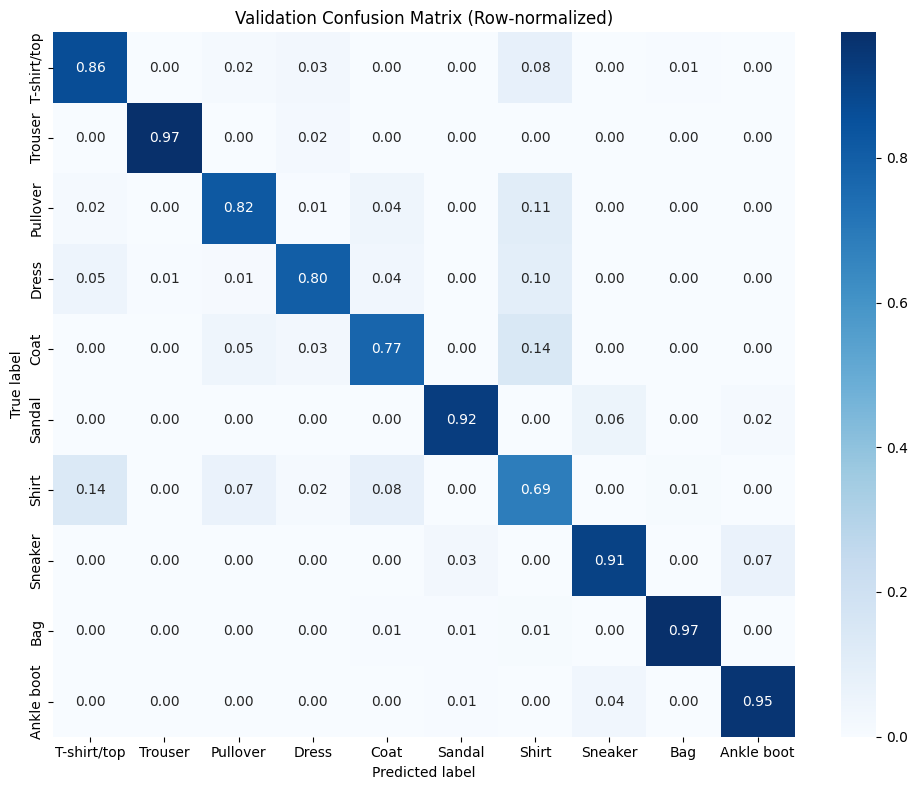

              precision    recall  f1-score   support

 T-shirt/top     0.8031    0.8633    0.8321       600
     Trouser     0.9915    0.9733    0.9823       600
    Pullover     0.8466    0.8183    0.8322       600
       Dress     0.8842    0.8017    0.8409       600
        Coat     0.8183    0.7733    0.7952       600
      Sandal     0.9585    0.9233    0.9406       600
       Shirt     0.6053    0.6850    0.6427       600
     Sneaker     0.9080    0.9050    0.9065       600
         Bag     0.9749    0.9717    0.9733       600
  Ankle boot     0.9180    0.9517    0.9345       600

    accuracy                         0.8667      6000
   macro avg     0.8708    0.8667    0.8680      6000
weighted avg     0.8708    0.8667    0.8680      6000


Delta vs previous single-split baseline (negative to positive):


,class,precision_cur,precision_base,precision_delta,recall_cur,recall_base,recall_delta,f1_cur,f1_base,f1_delta
3,Dress,0.8842,0.8735,+0.0107,0.8017,0.8517,-0.0500,0.8409,0.8624,-0.0215
5,Sandal,0.9585,0.9513,+0.0072,0.9233,0.9433,-0.0200,0.9406,0.9473,-0.0067
2,Pullover,0.8466,0.8242,+0.0224,0.8183,0.8517,-0.0334,0.8322,0.8377,-0.0055
7,Sneaker,0.9080,0.9276,-0.0196,0.9050,0.8967,+0.0083,0.9065,0.9119,-0.0054
4,Coat,0.8183,0.7997,+0.0186,0.7733,0.7983,-0.0250,0.7952,0.7990,-0.0038
8,Bag,0.9749,0.9718,+0.0031,0.9717,0.9767,-0.0050,0.9733,0.9742,-0.0009
9,Ankle boot,0.9180,0.9140,+0.0040,0.9517,0.9567,-0.0050,0.9345,0.9349,-0.0004
1,Trouser,0.9915,0.9865,+0.0050,0.9733,0.9750,-0.0017,0.9823,0.9807,+0.0016
0,T-shirt/top,0.8031,0.7886,+0.0145,0.8633,0.8767,-0.0134,0.8321,0.8303,+0.0018
6,Shirt,0.6053,0.6717,-0.0664,0.6850,0.5933,+0.0917,0.6427,0.6301,+0.0126



Top classes by F1 gain:


,class,f1_delta
6,Shirt,0.012590
0,T-shirt/top,0.001829
1,Trouser,0.001638



Most degraded classes by F1:


,class,f1_delta
3,Dress,-0.021491
5,Sandal,-0.006723
2,Pullover,-0.005497


In [13]:
# Confusion matrix, per-class report, and delta vs previous single-split run
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
 ]

cm = confusion_matrix(y_val, val_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Validation Confusion Matrix (Row-normalized)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

report_dict = classification_report(
    y_val, val_pred, target_names=class_names, digits=4, output_dict=True
)
print(classification_report(y_val, val_pred, target_names=class_names, digits=4))

# Baseline from your previous single train/val split
baseline_single_split = {
    'T-shirt/top': {'precision': 0.7886, 'recall': 0.8767, 'f1-score': 0.8303},
    'Trouser': {'precision': 0.9865, 'recall': 0.9750, 'f1-score': 0.9807},
    'Pullover': {'precision': 0.8242, 'recall': 0.8517, 'f1-score': 0.8377},
    'Dress': {'precision': 0.8735, 'recall': 0.8517, 'f1-score': 0.8624},
    'Coat': {'precision': 0.7997, 'recall': 0.7983, 'f1-score': 0.7990},
    'Sandal': {'precision': 0.9513, 'recall': 0.9433, 'f1-score': 0.9473},
    'Shirt': {'precision': 0.6717, 'recall': 0.5933, 'f1-score': 0.6301},
    'Sneaker': {'precision': 0.9276, 'recall': 0.8967, 'f1-score': 0.9119},
    'Bag': {'precision': 0.9718, 'recall': 0.9767, 'f1-score': 0.9742},
    'Ankle boot': {'precision': 0.9140, 'recall': 0.9567, 'f1-score': 0.9349},
}

rows = []
for c in class_names:
    cur = report_dict[c]
    base = baseline_single_split[c]
    rows.append({
        'class': c,
        'precision_cur': cur['precision'],
        'precision_base': base['precision'],
        'precision_delta': cur['precision'] - base['precision'],
        'recall_cur': cur['recall'],
        'recall_base': base['recall'],
        'recall_delta': cur['recall'] - base['recall'],
        'f1_cur': cur['f1-score'],
        'f1_base': base['f1-score'],
        'f1_delta': cur['f1-score'] - base['f1-score'],
    })

delta_df = pd.DataFrame(rows).sort_values('f1_delta')
print('\nDelta vs previous single-split baseline (negative to positive):')
display(delta_df.style.format({
    'precision_cur': '{:.4f}', 'precision_base': '{:.4f}', 'precision_delta': '{:+.4f}',
    'recall_cur': '{:.4f}', 'recall_base': '{:.4f}', 'recall_delta': '{:+.4f}',
    'f1_cur': '{:.4f}', 'f1_base': '{:.4f}', 'f1_delta': '{:+.4f}',
}))

print('\nTop classes by F1 gain:')
display(delta_df.sort_values('f1_delta', ascending=False).head(3)[['class', 'f1_delta']])

print('\nMost degraded classes by F1:')
display(delta_df.head(3)[['class', 'f1_delta']])

Shirt -> T-shirt/top errors: 83


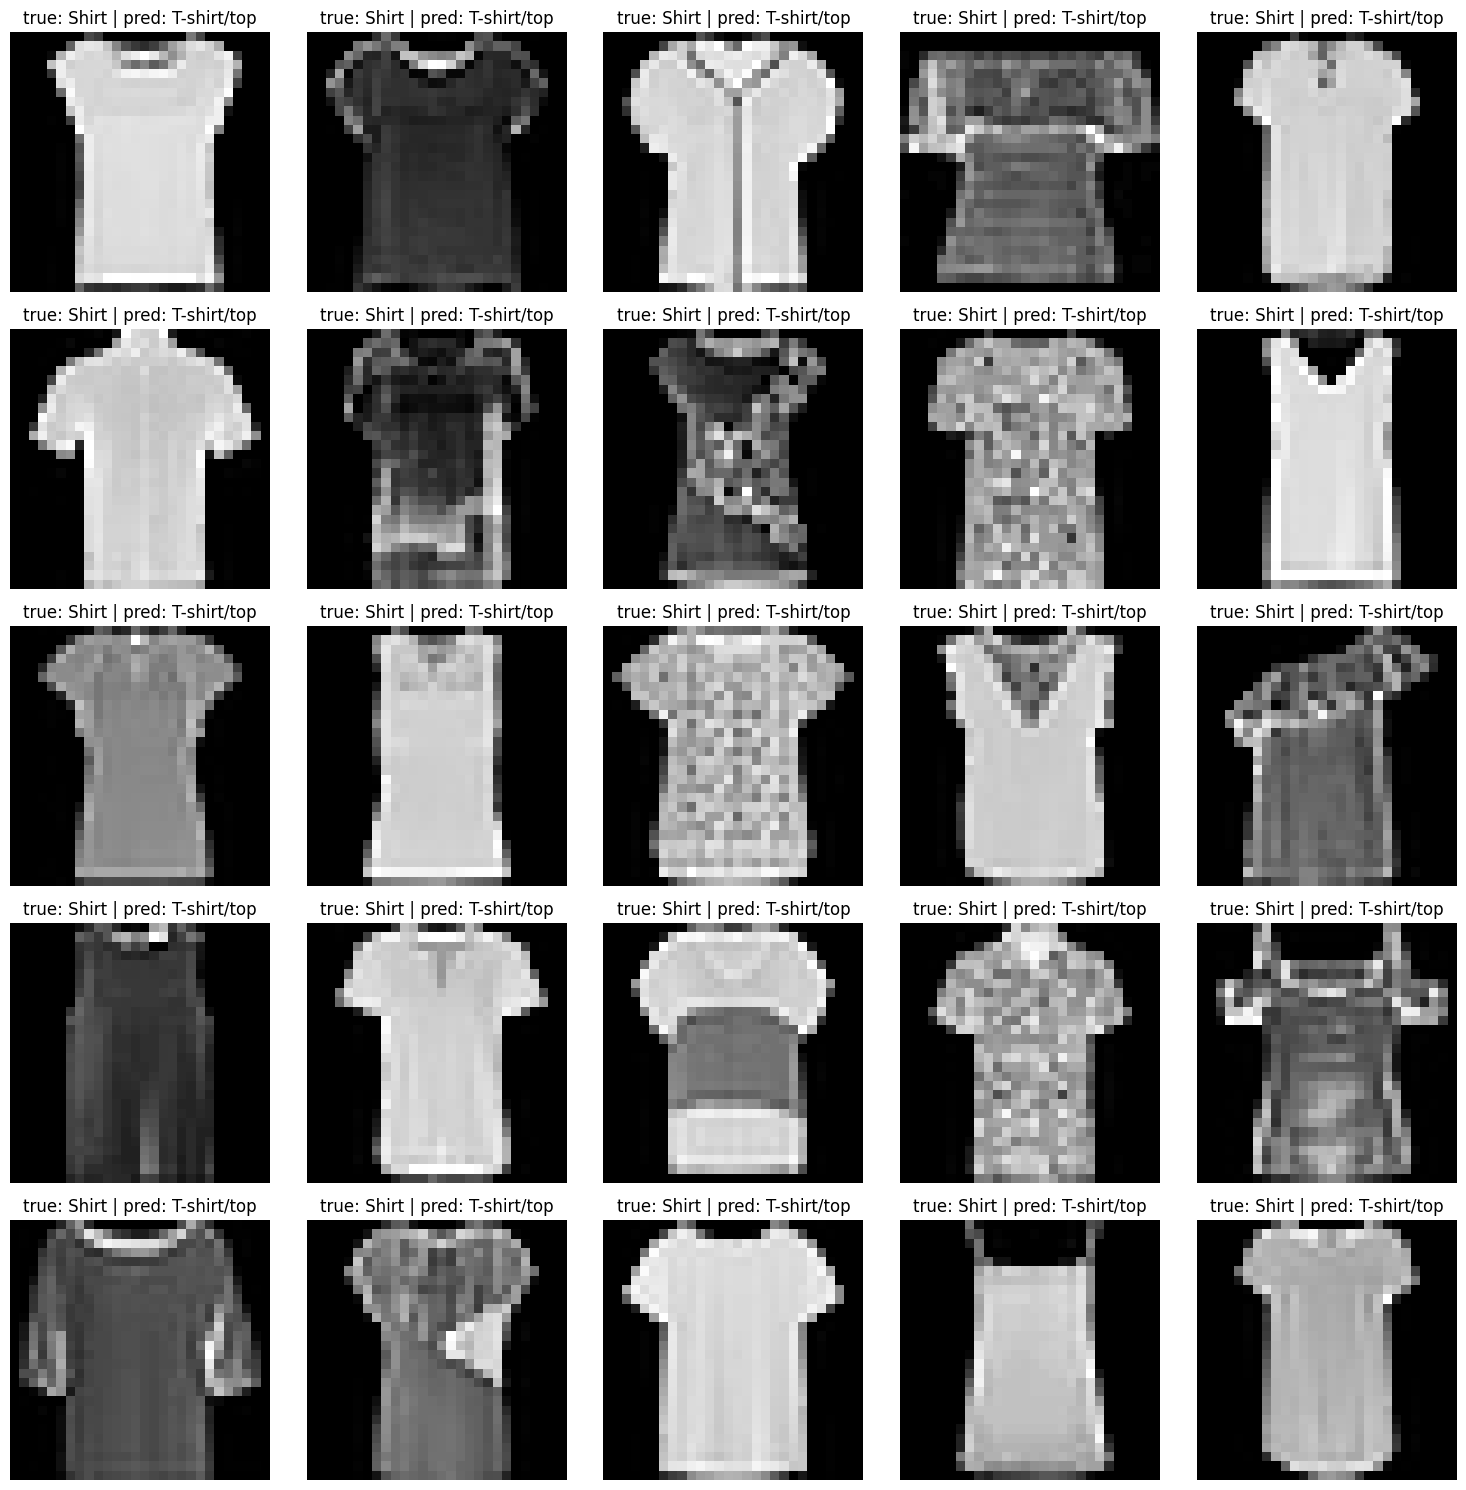

In [11]:
# Error visualization: true Shirt (6) predicted as T-shirt/top (0)
error_mask = (y_val == 6) & (val_pred == 0)
error_idx = np.where(error_mask)[0]

print(f'Shirt -> T-shirt/top errors: {len(error_idx)}')

if len(error_idx) == 0:
    print('No Shirt -> T-shirt/top errors in this run.')
else:
    n_show = min(25, len(error_idx))
    shown = error_idx[:n_show]

    cols = 5
    rows = int(np.ceil(n_show / cols))
    plt.figure(figsize=(3 * cols, 3 * rows))

    for i, idx in enumerate(shown, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(X_val[idx].reshape(28, 28), cmap='gray')
        plt.title('true: Shirt | pred: T-shirt/top')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [12]:
# Test prediction and submission
test_pred = np.argmax(test_probs, axis=1)

submission = sample_sub.copy()
submission['label'] = test_pred
submission_path = './submission.csv'
submission.to_csv(submission_path, index=False)

np.save('./test_probs.npy', test_probs)
print('Saved submission:', submission_path)
print('Saved test probabilities: ./test_probs.npy')
submission.head()

NameError: name 'test_probs' is not defined